In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


# Importamos las librerias de redes neuronales con sus principales métodos
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
# Leer y cargar conjunto de datos
df = pd.read_csv('https://raw.githubusercontent.com/Noelia1986-A/DS-III/refs/heads/main/student_performance_dataset.csv')

Exploración del dataset

In [ ]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [ ]:
df.shape

(1000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [ ]:
df = df.drop(columns=['gender', 'parental_education', 'internet_access' , 'extracurricular_activities' , 'part_time_job'])

In [ ]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [ ]:
# Separar las características (X) y las etiquetas (y)
X = df.drop('final_grade', axis=1)
y = df['final_grade']
X.head()


,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
0,1,4.0,98.0,6.5,76.9,100.0
1,2,6.3,100.0,5.7,75.5,100.0
2,3,4.9,85.3,7.9,88.5,97.3
3,4,2.6,77.5,8.0,85.1,83.8
4,5,2.2,89.6,4.6,61.8,68.3


In [ ]:
y.head()

,final_grade
0,A
1,A
2,A
3,B
4,D


Codificación de etiquetas

In [ ]:
from sklearn.preprocessing import LabelEncoder


# Crear el codificador de etiquetas
label_encoder = LabelEncoder()

# Aplicar el codificador a la variable objetivo "final_grade"
y = label_encoder.fit_transform(y)

In [ ]:
y

array([0, 0, 0, 1, 3, 1, 3, 1, 1, 2, 3, 2, 1, 0, 2, 1, 1, 2, 1, 0, 2, 0,
       2, 2, 0, 2, 2, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 0, 2,
       2, 3, 3, 1, 1, 3, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0,
       3, 2, 2, 1, 2, 2, 0, 2, 0, 3, 2, 2, 2, 1, 0, 2, 3, 0, 0, 3, 2, 0,
       2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 3, 2, 2, 3, 1, 0, 1, 0, 2, 2, 0, 2,
       3, 0, 2, 2, 0, 0, 4, 0, 2, 2, 0, 1, 2, 1, 1, 0, 1, 3, 1, 1, 0, 2,
       2, 1, 1, 0, 4, 1, 1, 1, 1, 2, 1, 3, 1, 3, 1, 4, 3, 3, 1, 2, 1, 2,
       0, 1, 1, 1, 3, 2, 1, 2, 0, 0, 1, 1, 0, 1, 2, 2, 0, 2, 2, 1, 2, 1,
       1, 1, 0, 2, 2, 2, 2, 1, 1, 0, 1, 1, 0, 3, 1, 0, 2, 1, 0, 2, 2, 0,
       1, 0, 0, 2, 1, 2, 1, 3, 0, 0, 0, 2, 1, 1, 2, 2, 1, 2, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 3, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       3, 0, 2, 0, 0, 2, 1, 3, 1, 0, 2, 1, 1, 0, 1, 3, 2, 0, 2, 2, 1, 0,
       0, 0, 1, 1, 0, 1, 2, 2, 3, 0, 2, 2, 2, 1, 0, 4, 1, 1, 3, 1, 1, 3,
       3, 3, 2, 2, 0, 0, 1, 0, 0, 1, 2, 1, 3, 1, 1,

In [ ]:
# las redes neuronales son muy sensibles a datos no escalados
scaler_labels = StandardScaler()
X= scaler_labels.fit_transform(X)

In [ ]:
#Separo los datos de "train" en entrenamiento y prueba "test" para probar los algoritmos
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Defino la función neuronal
def define_model():

    keras.backend.clear_session()
    # se eliminan todos los modelos y operaciones creados en la sesión actual, libera memoria y permita una construcción en limpio
    model = keras.models.Sequential()
    # se utiliza para crear un modelo secuencial en deep learning. Un modelo secuencial es una pila de capas donde la salida de una capa es la entrada de la siguiente capa.

     # 2 capas ocultas con función de activación relu
    model.add(keras.layers.Dense(10, input_dim=5, kernel_initializer='normal', activation='relu'))
    model.add(keras.layers.Dense(5, kernel_initializer='normal', activation='relu'))
    #capa de salida
    model.add(keras.layers.Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

    # kernel_initializer='normal', los pesos de las capas densas se inicializan aleatoriamente según la distribución normal.
    # La función de pérdida (loss function) se utiliza durante el entrenamiento para optimizar los pesos del modelo
    # El optimizador "adam" se utiliza para ajustar los pesos del modelo durante el entrenamiento.
    # Las métricas de evaluación accuracy para monitorear durante el entrenamiento

In [ ]:
# Redefine define_model with the correct input_dim and output units for this cell's execution
def define_model():
    keras.backend.clear_session()
    model = keras.models.Sequential()
    model.add(keras.layers.Dense(10, input_dim=6, kernel_initializer='normal', activation='relu')) # Corrected input_dim to 6
    model.add(keras.layers.Dense(5, kernel_initializer='normal', activation='relu'))
    model.add(keras.layers.Dense(5, activation='softmax')) # Corrected output units to 5
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = define_model()

#Early es un buen metodo de regularizacion, en patience aplicamos un 30 para que al menos tengan que pasar 30 epoch antes de hacer una parada.
early = keras.callbacks.EarlyStopping(patience=30, monitor='val_loss', restore_best_weights=True)
history = model.fit(epochs=300, batch_size=32, x=x_train, y=y_train, validation_data=(x_test, y_test), callbacks=[early])

Epoch 1/300


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3414 - loss: 1.6042 - val_accuracy: 0.3467 - val_loss: 1.5957
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3571 - loss: 1.5857 - val_accuracy: 0.3467 - val_loss: 1.5769
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3571 - loss: 1.5643 - val_accuracy: 0.3467 - val_loss: 1.5536
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3571 - loss: 1.5370 - val_accuracy: 0.3467 - val_loss: 1.5218
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3571 - loss: 1.5016 - val_accuracy: 0.3467 - val_loss: 1.4803
Epoch 6/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3571 - loss: 1.4566 - val_accuracy: 0.3467 - val_loss: 1.4289
Epoch 7/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4014 - loss: 1.4037 - val_accuracy: 0.4967 - val_loss: 1.3704
Epoch 8/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5571 - loss: 1.3466 - val_accuracy: 0.5033 - val_loss: 1

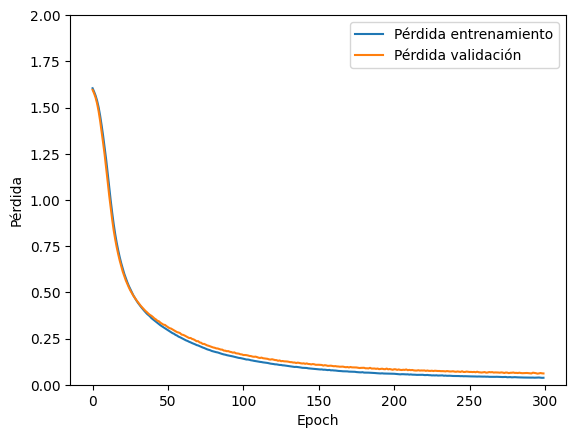

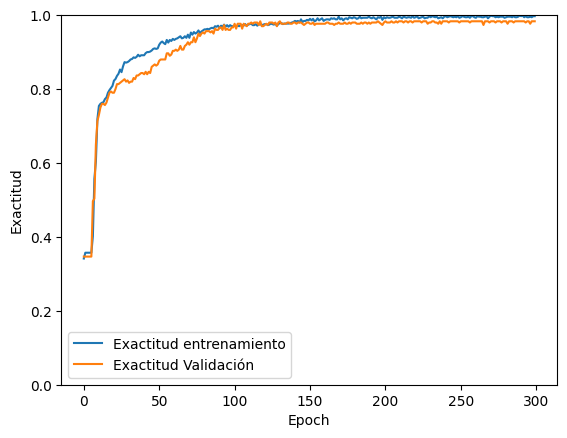

In [ ]:
# EVALUACIÓN DEL MODELO

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Pérdida')
    plt.plot(hist['epoch'], hist['loss'],
           label='Pérdida entrenamiento')
    plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Pérdida validación')
    plt.ylim([0,2])
    plt.legend()

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Exactitud')
    plt.plot(hist['epoch'], hist['accuracy'],
           label='Exactitud entrenamiento')
    plt.plot(hist['epoch'], hist['val_accuracy'],
           label = 'Exactitud Validación')
    plt.ylim([0,1])
    plt.legend()
    plt.show()


plot_history(history)

# una buena red es aquella donde la función de perdida en test y train es baja

In [ ]:
# Predicciones sobre TEST (datos que el modelo no vio en el entrenamiento)
y_pred = model.predict(x_test)
y_pred_c = np.argmax(y_pred, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
y_pred

array([[8.11808447e-33, 1.90248812e-07, 9.36134994e-01, 6.38647377e-02,
        1.52412866e-07],
       [0.00000000e+00, 7.25801689e-13, 5.63978404e-03, 9.93331730e-01,
        1.02841889e-03],
       [0.00000000e+00, 2.32538750e-15, 1.04969666e-04, 9.63257730e-01,
        3.66373509e-02],
       ...,
       [9.99993801e-01, 6.15461931e-06, 6.39739455e-13, 0.00000000e+00,
        0.00000000e+00],
       [1.60978361e-05, 9.99961376e-01, 2.25678432e-05, 1.66367534e-22,
        0.00000000e+00],
       [1.77476340e-05, 9.99950647e-01, 3.15747675e-05, 1.26295808e-21,
        0.00000000e+00]], dtype=float32)

In [ ]:
y_pred_c

array([2, 3, 3, 0, 1, 3, 0, 2, 3, 4, 1, 2, 0, 2, 2, 3, 1, 0, 2, 1, 1, 2,
       1, 0, 1, 1, 3, 1, 2, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 3, 1, 0, 3,
       1, 1, 2, 0, 0, 1, 3, 1, 2, 1, 2, 1, 2, 3, 2, 3, 2, 0, 1, 2, 1, 0,
       0, 1, 2, 0, 2, 1, 1, 0, 1, 2, 1, 0, 2, 2, 1, 3, 2, 2, 1, 0, 1, 0,
       3, 1, 2, 1, 1, 1, 0, 0, 1, 2, 2, 1, 0, 1, 1, 1, 0, 1, 3, 1, 2, 1,
       1, 0, 0, 1, 2, 2, 1, 1, 1, 0, 2, 1, 0, 2, 1, 2, 3, 2, 0, 1, 1, 0,
       0, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 0, 2, 3, 2, 2,
       1, 0, 1, 0, 1, 0, 1, 2, 0, 3, 1, 0, 3, 3, 0, 1, 0, 1, 3, 0, 3, 2,
       1, 0, 0, 3, 1, 3, 2, 1, 2, 1, 2, 2, 3, 0, 0, 0, 1, 0, 2, 1, 1, 0,
       2, 2, 1, 2, 2, 2, 0, 1, 1, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 3, 1, 0,
       1, 2, 3, 3, 0, 0, 3, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 2, 1, 1, 1,
       0, 0, 1, 2, 1, 2, 0, 3, 3, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 3, 2, 2, 0, 2, 2, 3, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 1, 1,
       2, 3, 1, 2, 2, 0, 0, 3, 3, 0, 1, 0, 1, 1])

In [ ]:
from sklearn.metrics import classification_report

# Reporte de clasificación sobre TEST: así medimos generalización, no memorización
classification_summary = classification_report(y_test, y_pred_c)
print(classification_summary)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        77
           1       0.97      0.99      0.98       104
           2       0.99      1.00      0.99        83
           3       0.97      1.00      0.99        34
           4       1.00      0.50      0.67         2

    accuracy                           0.98       300
   macro avg       0.99      0.89      0.92       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
cm = confusion_matrix(y_test, y_pred_c)

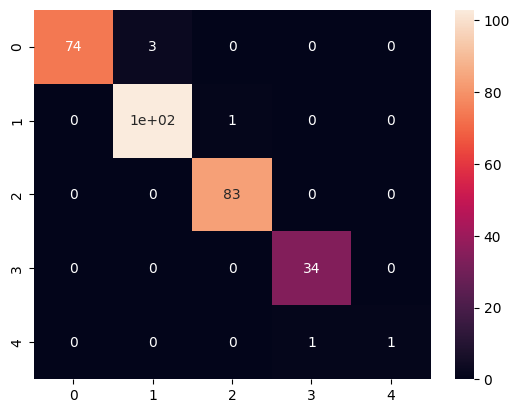

In [ ]:
sns.heatmap(cm,annot=True)
plt.savefig('h.png')